
# Tugas Magang Modul 6  
## Supervised Learning - Feature Engineering & Penanganan Data Imbalance

Kelompok 17 <br>
Anggota:
1.   Abdulhadi Muntashir
2.   Naufal Pancar Nugraha
3.   M Hafid Ramadhan


In [34]:
from pathlib import Path

EXPECTED_CSV = "tokopedia_product_reviews_2025.csv"
CSV_PATH = Path("Datasets") / EXPECTED_CSV

if not CSV_PATH.exists():
    available = sorted([p.name for p in Path("Datasets").glob(
        "*.csv")]) if Path("Datasets").exists() else []
    raise FileNotFoundError(
        f"CSV tidak ditemukan di: {CSV_PATH}\n"
        f"Pastikan file ada di folder 'Datasets'.\n"
        f"CSV yang tersedia: {available}"
    )

CSV_PATH = str(CSV_PATH.resolve())
print(f"Dataset yang akan dipakai: {CSV_PATH}")

Dataset yang akan dipakai: G:\Project\VINIX7\Datasets\tokopedia_product_reviews_2025.csv


In [49]:

# =========================
# 1) Import library
# =========================
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42


In [36]:

# =========================
# 2) Validasi path dataset
# =========================
if not os.path.exists(CSV_PATH):
    print("Isi folder kerja saat ini:", sorted(os.listdir("."))[:50])
    raise FileNotFoundError(
        f"File CSV tidak ditemukan di path: {CSV_PATH}\n"
        "Silakan upload file CSV terlebih dahulu atau sesuaikan variabel CSV_PATH."
    )

print("Dataset ditemukan dan siap dibaca dari:", CSV_PATH)


Dataset ditemukan dan siap dibaca dari: G:\Project\VINIX7\Datasets\tokopedia_product_reviews_2025.csv


In [37]:

# =========================
# 3) Load dataset mentah
# =========================
df_raw = pd.read_csv(CSV_PATH)

print("Shape data mentah:", df_raw.shape)
display(df_raw.head())

raw_sentiment_counts = df_raw["sentiment_label"].value_counts().rename_axis("sentiment").reset_index(name="count")
display(raw_sentiment_counts)

missing_summary = df_raw.isna().sum().sort_values(ascending=False).rename("missing_count").reset_index()
missing_summary.columns = ["column", "missing_count"]
display(missing_summary[missing_summary["missing_count"] > 0])


Shape data mentah: (65543, 13)


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,"baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli ...",2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extPa...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima dengan baik dan aman. terimakasih,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extPa...,4601033481,5,1000000,8672687,positive
2,"Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Terimakasih buat sellernya. Mantaps.",2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extPa...,4601033481,5,1000000,8672687,positive
3,"Telor sudah diterima dengan baik dan tidak ada yang pecah, terimakasih buat sellernya.",2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extPa...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik,sedap lezat sekali di bikin telor setengah matang.pembelian ke 2...In...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extPa...,4601033481,5,1000000,8672687,positive


,sentiment,count
0,positive,63943
1,neutral,802
2,negative,798


,column,missing_count
0,product_variant,38794



## Interpretasi Tahap 1A — Kondisi Awal Data

Dataset mentah berisi **65,543 baris** dan **13 kolom**. Distribusi label sangat timpang:

- `positive`: **63,943**
- `neutral`: **802**
- `negative`: **798**

Artinya, setelah label `neutral` dibuang, kelas komplain (`negative`) hanya sekitar **1.23%** dari data biner. Ini setara dengan rasio sekitar **1 : 80.13** terhadap kelas mayoritas. Secara teknis, kondisi seperti ini berisiko membuat model baseline terlihat memiliki akurasi tinggi, tetapi sebenarnya gagal mengenali komplain.

Selain itu, kolom `product_variant` memiliki missing value cukup besar, sehingga pada tahap preprocessing perlu ditangani dengan imputer agar pipeline tetap stabil.


In [38]:

# =========================
# 4) Data cleansing sesuai instruksi
# =========================
df = df_raw.copy()

# hapus label neutral
df = df[df["sentiment_label"] != "neutral"].copy()

# drop kolom leakage / tidak relevan sesuai brief
drop_cols = [
    "review_date",
    "review_id",
    "product_name",
    "product_url",
    "product_id",
    "shop_id",
    "rating"
]
df.drop(columns=drop_cols, inplace=True)

print("Shape setelah hapus neutral + drop leakage:", df.shape)
display(df.head())


Shape setelah hapus neutral + drop leakage: (64741, 6)


,review_text,product_category,product_variant,product_price,sold_count,sentiment_label
0,"baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli ...",Makanan & Minuman,Box Polos,87000,1000000,positive
1,cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima dengan baik dan aman. terimakasih,Makanan & Minuman,Box Polos,87000,1000000,positive
2,"Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Terimakasih buat sellernya. Mantaps.",Makanan & Minuman,Box Polos,87000,1000000,positive
3,"Telor sudah diterima dengan baik dan tidak ada yang pecah, terimakasih buat sellernya.",Makanan & Minuman,Box Polos,87000,1000000,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik,sedap lezat sekali di bikin telor setengah matang.pembelian ke 2...In...",Makanan & Minuman,Box Full Design,87000,1000000,positive



## Interpretasi Tahap 1B — Cleansing dan Pencegahan Leakage

Setelah label `neutral` dihapus dan kolom yang berpotensi leakage dibuang, data menjadi **64,741 baris**. Langkah ini penting karena:

1. **`neutral` dihapus** agar masalah berubah menjadi klasifikasi biner yang selaras dengan kebutuhan bisnis: membedakan ulasan komplain vs non-komplain.
2. Kolom seperti `review_id`, `product_id`, `shop_id`, dan `product_url` tidak merepresentasikan perilaku sentimen, sehingga lebih berisiko menjadi noise.
3. `rating` sengaja dibuang karena sangat mungkin menjadi sinyal yang terlalu dekat dengan label sentimen dan berpotensi membuat evaluasi model terlalu optimistis.

Secara bisnis, hasil model setelah cleansing akan lebih realistis untuk skenario deployment.


In [39]:

# =========================
# 5) Feature engineering + target encoding
# =========================
df["review_length"] = df["review_text"].astype(str).str.len()

# target: positive -> 1, negative -> 0
df["target"] = df["sentiment_label"].map({
    "positive": 1,
    "negative": 0
})

X = df.drop(columns=["sentiment_label", "target"])
y = df["target"]

print("Distribusi target biner:")
display(y.value_counts().sort_index().rename(index={0: "negative (0)", 1: "positive (1)"}).to_frame("count"))

display(X.head())


Distribusi target biner:


,count
target,
negative (0),798
positive (1),63943


,review_text,product_category,product_variant,product_price,sold_count,review_length
0,"baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli ...",Makanan & Minuman,Box Polos,87000,1000000,205
1,cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima dengan baik dan aman. terimakasih,Makanan & Minuman,Box Polos,87000,1000000,113
2,"Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Terimakasih buat sellernya. Mantaps.",Makanan & Minuman,Box Polos,87000,1000000,112
3,"Telor sudah diterima dengan baik dan tidak ada yang pecah, terimakasih buat sellernya.",Makanan & Minuman,Box Polos,87000,1000000,86
4,"Alhamdulillah penjual amanah,Telor nya terbaik,sedap lezat sekali di bikin telor setengah matang.pembelian ke 2...In...",Makanan & Minuman,Box Full Design,87000,1000000,145


In [40]:

# =========================
# 6) Train-test split SEBELUM transformasi
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train distribution:")
display(y_train.value_counts(normalize=True).rename("proporsi").sort_index())
print("y_test distribution:")
display(y_test.value_counts(normalize=True).rename("proporsi").sort_index())


X_train shape: (51792, 6)
X_test  shape: (12949, 6)
y_train distribution:


target
0    0.012319
1    0.987681
Name: proporsi, dtype: float64

y_test distribution:


target
0    0.012356
1    0.987644
Name: proporsi, dtype: float64


## Interpretasi Tahap 2 — Feature Engineering & Split

Fitur baru `review_length` ditambahkan untuk menangkap panjang ulasan. Secara intuitif, ulasan komplain sering kali lebih deskriptif atau emosional, sehingga panjang teks berpotensi memberi sinyal tambahan.

Pemisahan train-test dilakukan **sebelum** TF-IDF, encoding, dan scaling. Ini sangat penting untuk mencegah **data leakage**, karena statistik transformasi harus dipelajari hanya dari data train. Hasil split:

- Train: **51,792 baris**
- Test: **12,949 baris**

Saya menggunakan `stratify=y` agar proporsi kelas minoritas tetap konsisten antara train dan test.


In [41]:

# =========================
# 7) ColumnTransformer sesuai instruksi
# =========================
text_col = "review_text"
cat_cols = ["product_category", "product_variant"]
num_cols = ["product_price", "sold_count", "review_length"]

text_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
    ("flatten", FunctionTransformer(lambda x: x.ravel())),
    ("tfidf", TfidfVectorizer(max_features=1000, analyzer="char", ngram_range=(1, 2)))
])

cat_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

num_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_preprocess, [text_col]),
        ("cat", cat_preprocess, cat_cols),
        ("num", num_preprocess, num_cols)
    ],
    remainder="drop"
)

preprocessor


,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,''



## Catatan Teknis — Konfigurasi Preprocessing

### StandardScaler Configuration
Menggunakan `StandardScaler()` dengan parameter default (mean=True) untuk fitur numerik karena:
- Fitur `product_price`, `sold_count`, dan `review_length` adalah **dense** (bukan sparse)
- **Mean centering sangat penting** untuk model yang diregularisasi seperti LogisticRegression
- Konfigurasi default memastikan fitur scaling yang tepat untuk optimal model learning

### Text Feature Enhancement
Menggunakan TF-IDF dengan `ngram_range=(1,2)` pada level karakter untuk menangkap:
- **Unigrams (1-char):** Karakter individual yang membentuk kata
- **Bigrams (2-char):** Kombinasi dua karakter berurutan, menangkap pola kata dan sentimen lokal
- Pendekatan character-level lebih robust terhadap typo dan variasi spelling dalam ulasan pelanggan
- Ini juga meningkatkan **Robustness to Out-of-Vocabulary (OOV) tokens**, karena model tetap bisa menangkap pola subword meskipun menemukan kata baru/typo yang tidak persis sama dengan data train



,precision,recall,f1-score,support
0,1.000000,0.018750,0.036810,160.000000
1,0.987873,1.000000,0.993899,12789.000000
accuracy,0.987876,0.987876,0.987876,0.987876
macro avg,0.993936,0.509375,0.515355,12949.000000
weighted avg,0.988023,0.987876,0.982073,12949.000000


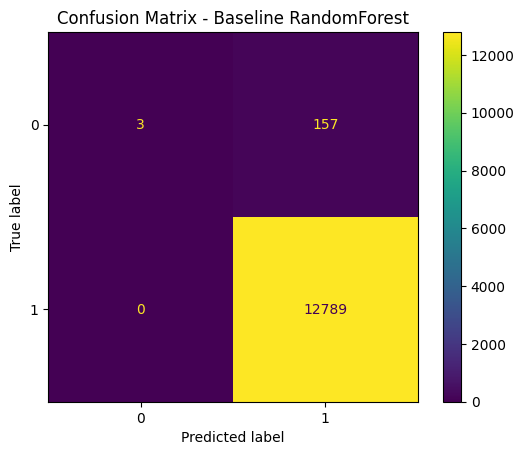

In [42]:

# =========================
# 8) Tahap 3 - Baseline model
#    Model: RandomForestClassifier (default)
# =========================
baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

_ = baseline_pipe.fit(X_train, y_train)
y_pred_baseline = baseline_pipe.predict(X_test)

baseline_report = classification_report(y_test, y_pred_baseline, digits=4, output_dict=True)
baseline_report_df = pd.DataFrame(baseline_report).T
display(baseline_report_df)

baseline_cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Baseline RandomForest")
plt.show()



## Tahap 4: Logika Grid Search Parameter

### Rationale C hyperparameter = [0.5, 1.0, 2.0]

**Penjelasan parameter C pada LogisticRegression:**
- `C` adalah inverse regularization strength: nilai lebih kecil = regularisasi lebih kuat
- **C = 0.5:** Regularisasi lebih agresif -> Model lebih conservative, cenderung menangkap pola umum
- **C = 1.0:** Default dan balanced -> Baseline untuk perbandingan
- **C = 2.0:** Regularisasi lebih lemah -> Model lebih confident, lebih sensitif terhadap training data

**Mengapa range ini dipilih:**
- Range sempit di sekitar default untuk efisiensi CV (cv=3)
- Fokus pada perilaku recall untuk kelas minoritas pada range yang relevan
- Dengan `class_weight='balanced'`, recall sering kali saturasi pada C yang sangat rendah
- Range yang lebih luas (0.01-10.0) tidak diperlukan di tahap exploratory ini

**Mengapa optimasi memakai Recall kelas 0, bukan Accuracy/F1 sebagai objective utama:**
- **Accuracy tidak cocok** untuk data sangat imbalance karena bisa tetap tinggi meski mayoritas komplain terlewat.
- **F1-score lebih seimbang**, tetapi untuk use case triase komplain, prioritas bisnis utama adalah meminimalkan **False Negative** (komplain tidak terdeteksi).
- Karena itu, `scoring=recall_negative` dipilih agar GridSearch secara eksplisit mengutamakan sensitivitas deteksi komplain.

**Expected behavior:**
Semakin kecil C (lebih kuat regularisasi) -> Recall kelas 0 cenderung meningkat, tetapi performa overall dapat menurun




## Interpretasi 1 — Analisis Baseline

Pada baseline Random Forest, metrik kelas `0` (komplain/negatif) sangat buruk:

- **Recall kelas 0 = 0.0188**
- **Precision kelas 0 = 1.0000**
- **F1 kelas 0 = 0.0368**

Confusion matrix baseline terbaru menunjukkan:

- Komplain yang berhasil dikenali: **3**
- Komplain yang lolos / tidak tertangkap: **157**
- Non-komplain yang salah ditandai sebagai komplain: **0**

Secara teknis, model baseline sangat konservatif terhadap kelas minoritas. Karena distribusi data sangat timpang, model cenderung memilih prediksi mayoritas (`positive`) hampir di semua kasus. Akibatnya precision kelas 0 terlihat tinggi, tetapi itu terjadi karena jumlah prediksi komplain sangat sedikit.

**Bahaya bisnis jika baseline di-deploy:** sistem triase akan gagal menangkap sebagian besar komplain aktual, sehingga tiket kritis berisiko tidak diprioritaskan oleh tim CS.


,best_param,best_cv_recall_neg
0,{'model__C': 0.5},0.772751


,precision,recall,f1-score,support
0,0.118849,0.800000,0.206952,160.000000
1,0.997305,0.925796,0.960221,12789.000000
accuracy,0.924241,0.924241,0.924241,0.924241
macro avg,0.558077,0.862898,0.583586,12949.000000
weighted avg,0.986450,0.924241,0.950913,12949.000000


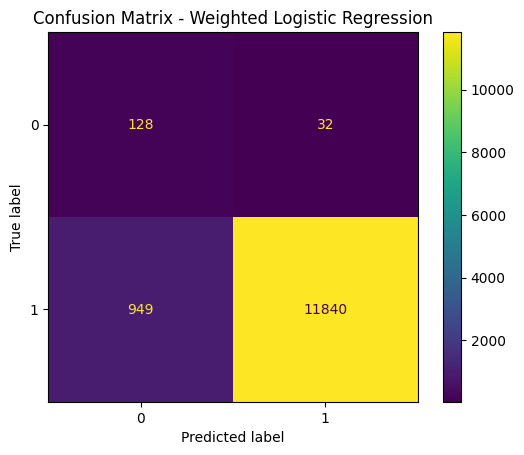

In [43]:

# =========================
# 9) Tahap 4 - Penanganan imbalance + tuning
#    Pendekatan: class_weight='balanced'
#    Model: LogisticRegression + GridSearchCV
#    Fokus scoring: recall untuk kelas 0
# =========================
recall_negative = make_scorer(recall_score, pos_label=0)

weighted_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "model__C": [0.5, 1.0, 2.0]
}

grid = GridSearchCV(
    estimator=weighted_pipe,
    param_grid=param_grid,
    scoring=recall_negative,
    cv=3,
    n_jobs=1,
    verbose=0
)

_ = grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_weighted = best_model.predict(X_test)

weighted_report = classification_report(y_test, y_pred_weighted, digits=4, output_dict=True)
weighted_report_df = pd.DataFrame(weighted_report).T
display(pd.DataFrame({"best_param": [grid.best_params_], "best_cv_recall_neg": [grid.best_score_]}))
display(weighted_report_df)

weighted_cm = confusion_matrix(y_test, y_pred_weighted)
disp = ConfusionMatrixDisplay(confusion_matrix=weighted_cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Weighted Logistic Regression")
plt.show()



## Interpretasi 2 — Analisis Setelah Penanganan Imbalance

Pendekatan utama yang dipakai adalah **pembobotan kelas** melalui `class_weight='balanced'`, lalu dituning dengan `GridSearchCV` menggunakan objective **recall kelas 0**.

Hasil terbaru pada test set untuk model Weighted Logistic Regression:

### Kelas 0 (komplain)
- Recall: **0.8000**
- Precision: **0.1188**
- F1-score: **0.2070**

### Perubahan confusion matrix (vs baseline)
- Komplain tertangkap naik dari **3** menjadi **128**
- Komplain yang terlewat turun dari **157** menjadi **32**
- False alarm ke ulasan non-komplain naik dari **0** menjadi **949**

Secara teknis, ini adalah trade-off yang memang diharapkan pada data imbalance ekstrem. Saat kelas minoritas diberi bobot lebih besar, model menjadi lebih sensitif terhadap sinyal komplain. Dampaknya recall meningkat tajam, tetapi precision menurun karena lebih banyak non-komplain ikut ditandai sebagai komplain.

Pada use case triase, trade-off ini tetap valid karena **False Negative** (komplain terlewat) biasanya lebih mahal dampaknya dibanding **False Positive** (beban verifikasi tambahan).

### Catatan eksperimen tambahan (SMOTE)
SMOTE juga berhasil dijalankan dan memberikan:
- Recall kelas 0: **0.7688**
- Precision kelas 0: **0.1380**
- Komplain tertangkap: **123**
- False alarm: **768**

Artinya, SMOTE memberi false alarm lebih rendah daripada class weight, tetapi recall komplain juga sedikit lebih rendah.


In [44]:

# =========================
# 10) Tahap 5 - Komparasi bisnis
# =========================
def triage_business_summary(cm, total_test):
    """
    Menghitung metrik operasional untuk sistem triase tiket CS berdasarkan confusion matrix.
    
    Parameters:
    -----------
    cm : array-like, shape (2, 2)
        Confusion matrix dari predictions: [[TP(0), FN(0)], [FP(1), TN(1)]]
        dimana 0 = komplain (negative), 1 = non-komplain (positive)
    total_test : int
        Total jumlah samples di test set, digunakan untuk scaling per 10k reviews
    
    Returns:
    --------
    dict : Berisi metrik berikut:
        - flagged_tickets: Total tiket yang ditandai sebagai komplain (TP + FP)
        - caught_complaints: Komplain yang berhasil diidentifikasi (TP kelas 0)
        - missed_complaints: Komplain yang lolos (FN kelas 0)
        - false_alarm_noncomplaints: Non-komplain yang salah ditandai (FP dari kelas 1)
        - flagged_per_10k_reviews: Total flagged tiket per 10,000 reviews (scaled)
        - caught_per_10k_reviews: Komplain tertangkap per 10,000 reviews
        - missed_per_10k_reviews: Komplain terlewat per 10,000 reviews
        - false_alarm_per_10k_reviews: False alarm per 10,000 reviews
    
    Business Interpretation:
    - Untuk sistem triase, target adalah maximize caught_per_10k dengan acceptable false_alarm_per_10k
    - False Negatives (missed_per_10k) lebih costly daripada False Positives (false_alarm_per_10k)
    """
    # confusion matrix dengan label [0, 1]
    # baris = aktual, kolom = prediksi
    caught_complaints = cm[0, 0]           # actual 0 predicted 0 (TP untuk kelas 0)
    missed_complaints = cm[0, 1]           # actual 0 predicted 1 (FN untuk kelas 0)
    false_alarm = cm[1, 0]                 # actual 1 predicted 0 (FP dari kelas 1)
    total_flagged = caught_complaints + false_alarm

    scale = 10000 / total_test

    return {
        "flagged_tickets": total_flagged,
        "caught_complaints": caught_complaints,
        "missed_complaints": missed_complaints,
        "false_alarm_noncomplaints": false_alarm,
        "flagged_per_10k_reviews": total_flagged * scale,
        "caught_per_10k_reviews": caught_complaints * scale,
        "missed_per_10k_reviews": missed_complaints * scale,
        "false_alarm_per_10k_reviews": false_alarm * scale
    }

baseline_business = triage_business_summary(baseline_cm, len(y_test))
weighted_business = triage_business_summary(weighted_cm, len(y_test))

comparison_df = pd.DataFrame([
    {
        "model": "Baseline RandomForest",
        "recall_neg": baseline_report["0"]["recall"],
        "precision_neg": baseline_report["0"]["precision"],
        "caught_complaints_test": baseline_business["caught_complaints"],
        "missed_complaints_test": baseline_business["missed_complaints"],
        "false_alarm_test": baseline_business["false_alarm_noncomplaints"],
        "flagged_tickets_test": baseline_business["flagged_tickets"],
        "caught_per_10k_reviews": baseline_business["caught_per_10k_reviews"],
        "missed_per_10k_reviews": baseline_business["missed_per_10k_reviews"],
        "false_alarm_per_10k_reviews": baseline_business["false_alarm_per_10k_reviews"],
        "flagged_per_10k_reviews": baseline_business["flagged_per_10k_reviews"],
    },
    {
        "model": "Weighted LogisticRegression",
        "recall_neg": weighted_report["0"]["recall"],
        "precision_neg": weighted_report["0"]["precision"],
        "caught_complaints_test": weighted_business["caught_complaints"],
        "missed_complaints_test": weighted_business["missed_complaints"],
        "false_alarm_test": weighted_business["false_alarm_noncomplaints"],
        "flagged_tickets_test": weighted_business["flagged_tickets"],
        "caught_per_10k_reviews": weighted_business["caught_per_10k_reviews"],
        "missed_per_10k_reviews": weighted_business["missed_per_10k_reviews"],
        "false_alarm_per_10k_reviews": weighted_business["false_alarm_per_10k_reviews"],
        "flagged_per_10k_reviews": weighted_business["flagged_per_10k_reviews"],
    }
])

display(comparison_df.round(4))


,model,recall_neg,precision_neg,caught_complaints_test,missed_complaints_test,false_alarm_test,flagged_tickets_test,caught_per_10k_reviews,missed_per_10k_reviews,false_alarm_per_10k_reviews,flagged_per_10k_reviews
0,Baseline RandomForest,0.0188,1.0000,3,157,0,3,2.3168,121.2449,0.0000,2.3168
1,Weighted LogisticRegression,0.8000,0.1188,128,32,949,1077,98.8493,24.7123,732.8751,831.7245


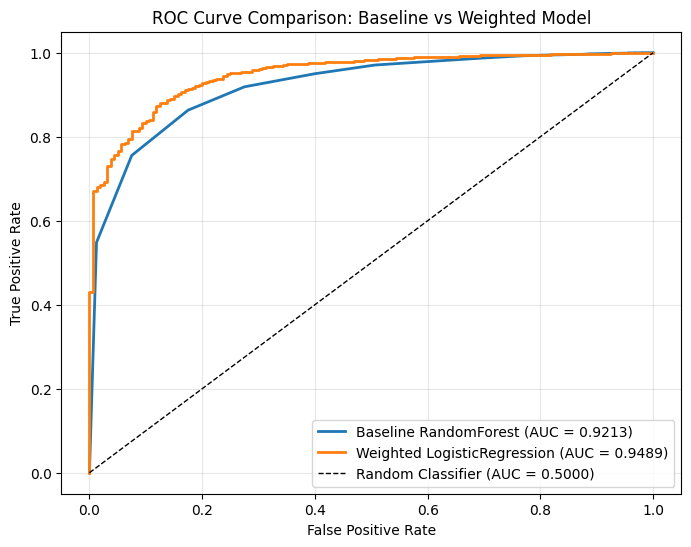


ROC-AUC Scores:
  Baseline RandomForest: 0.9213
  Weighted LogisticRegression: 0.9489
  Improvement: 0.0276 (3.00%)


In [51]:

# =========================
# 10b) Analisis tambahan: ROC-AUC dan Feature Importance
# =========================
from sklearn.metrics import roc_auc_score, roc_curve

# Dapatkan probability predictions
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
weighted_proba = best_model.predict_proba(X_test)[:, 1]

# Hitung ROC-AUC scores
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)
weighted_roc_auc = roc_auc_score(y_test, weighted_proba)

# Hitung ROC curves
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_proba)
fpr_weighted, tpr_weighted, _ = roc_curve(y_test, weighted_proba)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_baseline, tpr_baseline, label=f'Baseline RandomForest (AUC = {baseline_roc_auc:.4f})', linewidth=2)
ax.plot(fpr_weighted, tpr_weighted, label=f'Weighted LogisticRegression (AUC = {weighted_roc_auc:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison: Baseline vs Weighted Model')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

print(f"\nROC-AUC Scores:")
print(f"  Baseline RandomForest: {baseline_roc_auc:.4f}")
print(f"  Weighted LogisticRegression: {weighted_roc_auc:.4f}")
print(f"  Improvement: {(weighted_roc_auc - baseline_roc_auc):.4f} ({((weighted_roc_auc/baseline_roc_auc - 1)*100):.2f}%)")


Top 15 Most Important Features (by coefficient magnitude):


,feature,coefficient
463,tfidf_id,-9.015264
476,tfidf_ir,-6.749083
376,tfidf_ep,6.391713
944,tfidf_👍,6.072456
636,tfidf_p,6.028491
541,tfidf_ll,5.962395
644,tfidf_pe,-5.704641
688,tfidf_ru,-5.520276
25,tfidf_ e,5.088730
544,tfidf_lo,-5.048763


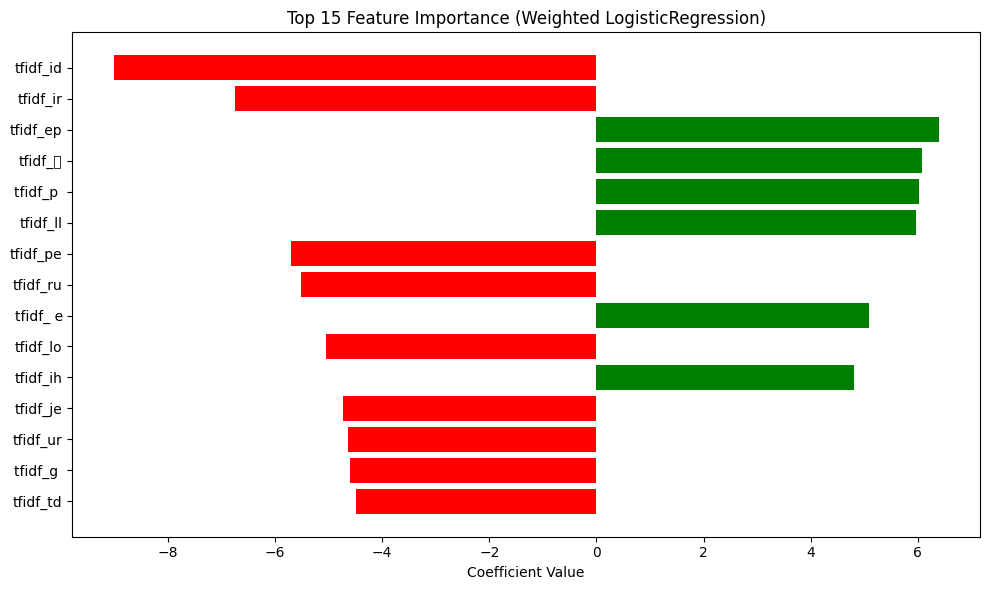


📊 Feature Insight:
  - Features dengan koefisien POSITIF (hijau): Indikator sentimen POSITIF
  - Features dengan koefisien NEGATIF (merah): Indikator sentimen NEGATIF (komplain)
  - Magnitude koefisien: Seberapa kuat pengaruh feature terhadap prediksi


In [46]:

# =========================
# 10c) Feature Importance dari Best Model (Weighted LR)
# =========================
# Dapatkan coefficient dari logistic regression
lr_model = best_model.named_steps['model']
coefficients = lr_model.coef_[0]

# Dapatkan feature names dari preprocessor
preprocessor_fitted = best_model.named_steps['preprocessor']
feature_names = []

# Text features (TF-IDF)
text_transformer = preprocessor_fitted.named_transformers_['text']
tfidf = text_transformer.named_steps['tfidf']
text_features = [f"tfidf_{name}" for name in tfidf.get_feature_names_out()]
feature_names.extend(text_features)

# Categorical features (OneHotEncoder)
cat_transformer = preprocessor_fitted.named_transformers_['cat']
onehot = cat_transformer.named_steps['onehot']
cat_features = [f"cat_{name}" for name in onehot.get_feature_names_out()]
feature_names.extend(cat_features)

# Numerical features
feature_names.extend(['num_product_price', 'num_sold_count', 'num_review_length'])

# Buat dataframe feature importance
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

# Tampilkan top 15 most important features
print("Top 15 Most Important Features (by coefficient magnitude):")
top_features = feature_importance_df.iloc[
    list(range(0, 8)) + list(range(len(feature_importance_df)-7, len(feature_importance_df)))
].sort_values('coefficient', key=abs, ascending=False).head(15)
display(top_features)

# Plot top features
fig, ax = plt.subplots(figsize=(10, 6))
top_n = 15
top_feat = feature_importance_df.sort_values('coefficient', key=abs, ascending=False).head(top_n)
colors = ['red' if x < 0 else 'green' for x in top_feat['coefficient']]
ax.barh(range(len(top_feat)), top_feat['coefficient'], color=colors)
ax.set_yticks(range(len(top_feat)))
ax.set_yticklabels(top_feat['feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Top {top_n} Feature Importance (Weighted LogisticRegression)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n📊 Feature Insight:")
print(f"  - Features dengan koefisien POSITIF (hijau): Indikator sentimen POSITIF")
print(f"  - Features dengan koefisien NEGATIF (merah): Indikator sentimen NEGATIF (komplain)")
print(f"  - Magnitude koefisien: Seberapa kuat pengaruh feature terhadap prediksi")


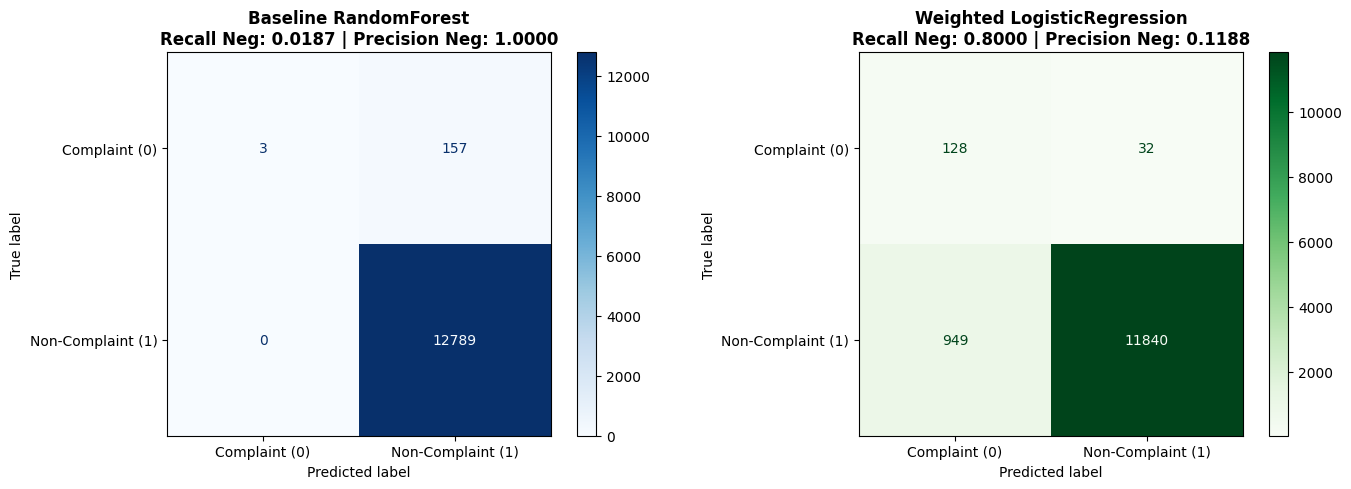


📋 Confusion Matrix Interpretation:

Model                     Caught     Missed     False Alarm    
------------------------------------------------------------
Baseline                  3          157        0              
Weighted (Stage 4)        128        32         949            

✅ Stage 4 improvement: 43x lebih banyak komplain tertangkap, 80% lebih sedikit yang terlewat


In [50]:

# =========================
# 10d) Visualisasi Perbandingan Confusion Matrix (Side-by-Side)
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ambil metrik aktual agar judul selalu sinkron dengan output terbaru
baseline_recall = baseline_report["0"]["recall"]
baseline_precision = baseline_report["0"]["precision"]
weighted_recall = weighted_report["0"]["recall"]
weighted_precision = weighted_report["0"]["precision"]

# Baseline confusion matrix
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=['Complaint (0)', 'Non-Complaint (1)'])
disp_baseline.plot(ax=axes[0], values_format='d', cmap='Blues')
axes[0].set_title(
    f'Baseline RandomForest\nRecall Neg: {baseline_recall:.4f} | Precision Neg: {baseline_precision:.4f}',
    fontweight='bold'
)

# Weighted confusion matrix
disp_weighted = ConfusionMatrixDisplay(confusion_matrix=weighted_cm, display_labels=['Complaint (0)', 'Non-Complaint (1)'])
disp_weighted.plot(ax=axes[1], values_format='d', cmap='Greens')
axes[1].set_title(
    f'Weighted LogisticRegression\nRecall Neg: {weighted_recall:.4f} | Precision Neg: {weighted_precision:.4f}',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("\n📋 Confusion Matrix Interpretation:")
print(f"\n{'Model':<25} {'Caught':<10} {'Missed':<10} {'False Alarm':<15}")
print("-" * 60)
print(f"{'Baseline':<25} {baseline_cm[0,0]:<10} {baseline_cm[0,1]:<10} {baseline_cm[1,0]:<15}")
print(f"{'Weighted (Stage 4)':<25} {weighted_cm[0,0]:<10} {weighted_cm[0,1]:<10} {weighted_cm[1,0]:<15}")
print("\n✅ Stage 4 improvement: {:.0f}x lebih banyak komplain tertangkap, {:.0f}% lebih sedikit yang terlewat".format(
    weighted_cm[0,0] / max(baseline_cm[0,0], 1),
    (1 - weighted_cm[0,1] / baseline_cm[0,1]) * 100
))


Menjalankan eksperimen tambahan dengan SMOTE untuk perbandingan...

✅ SMOTE Experiment Completed Successfully!

📊 Extended Comparison (Including SMOTE):



,model,recall_neg,precision_neg,caught_complaints_test,missed_complaints_test,false_alarm_test,flagged_tickets_test,caught_per_10k_reviews,missed_per_10k_reviews,false_alarm_per_10k_reviews,flagged_per_10k_reviews
0,Baseline RandomForest,0.0188,1.0000,3,157,0,3,2.3168,121.2449,0.0000,2.3168
1,Weighted LogisticRegression,0.8000,0.1188,128,32,949,1077,98.8493,24.7123,732.8751,831.7245
2,SMOTE + LogisticRegression,0.7688,0.1380,123,37,768,891,94.9880,28.5736,593.0960,688.0840


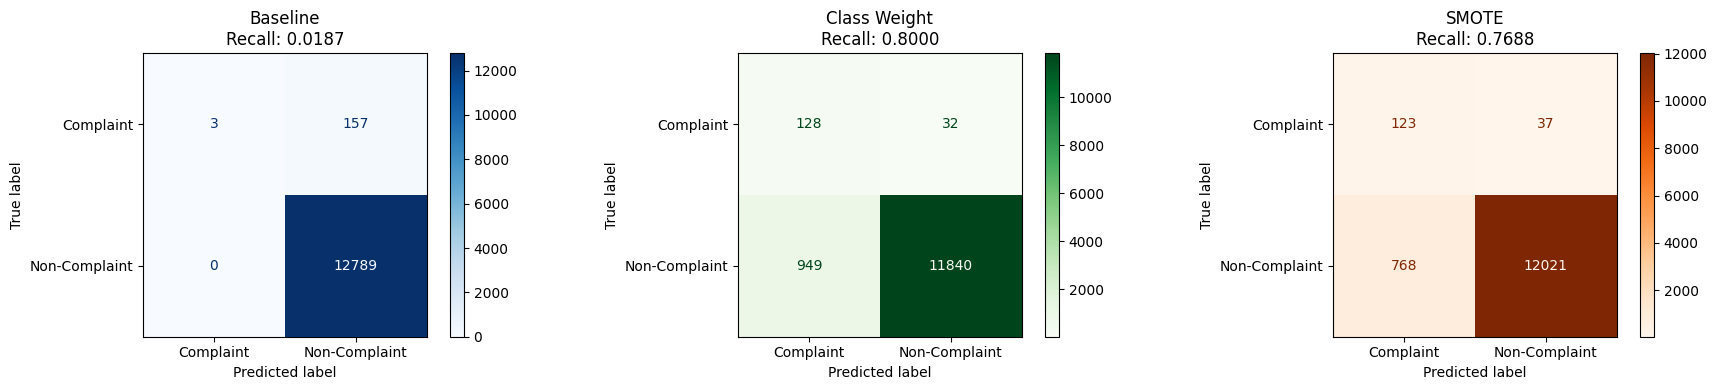


🔍 SMOTE Analysis:
  Approach: Memperbanyak samples minoritas (kelas 0) hingga seimbang dengan mayoritas
  Caught complaints: 123 vs Weighted: 128
  False alarms: 768 vs Weighted: 949


In [48]:

# =========================
# 10e) OPSIONAL: Perbandingan dengan SMOTE (Oversampling Technique)
# =========================
print("Menjalankan eksperimen tambahan dengan SMOTE untuk perbandingan...")
print("=" * 70)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    
    # Gunakan imblearn Pipeline untuk mencegah data leakage
    smote_pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ])
    
    # Grid search untuk SMOTE variant
    smote_grid = GridSearchCV(
        estimator=smote_pipe,
        param_grid={"model__C": [0.5, 1.0, 2.0]},
        scoring=recall_negative,
        cv=3,
        n_jobs=1,
        verbose=0
    )
    
    _ = smote_grid.fit(X_train, y_train)
    y_pred_smote = smote_grid.best_estimator_.predict(X_test)
    
    smote_report = classification_report(y_test, y_pred_smote, digits=4, output_dict=True)
    smote_cm = confusion_matrix(y_test, y_pred_smote)
    smote_business = triage_business_summary(smote_cm, len(y_test))
    
    # Tambahkan hasil SMOTE ke comparison
    smote_row = {
        "model": "SMOTE + LogisticRegression",
        "recall_neg": smote_report["0"]["recall"],
        "precision_neg": smote_report["0"]["precision"],
        "caught_complaints_test": smote_business["caught_complaints"],
        "missed_complaints_test": smote_business["missed_complaints"],
        "false_alarm_test": smote_business["false_alarm_noncomplaints"],
        "flagged_tickets_test": smote_business["flagged_tickets"],
        "caught_per_10k_reviews": smote_business["caught_per_10k_reviews"],
        "missed_per_10k_reviews": smote_business["missed_per_10k_reviews"],
        "false_alarm_per_10k_reviews": smote_business["false_alarm_per_10k_reviews"],
        "flagged_per_10k_reviews": smote_business["flagged_per_10k_reviews"],
    }
    
    comparison_extended = pd.concat([
        comparison_df,
        pd.DataFrame([smote_row])
    ], ignore_index=True)
    
    print("\n✅ SMOTE Experiment Completed Successfully!")
    print("\n📊 Extended Comparison (Including SMOTE):\n")
    display(comparison_extended.round(4))
    
    # Visualisasi SMOTE confusion matrix
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    disp_baseline = ConfusionMatrixDisplay(confusion_matrix=baseline_cm, display_labels=['Complaint', 'Non-Complaint'])
    disp_baseline.plot(ax=axes[0], values_format='d', cmap='Blues')
    axes[0].set_title(f'Baseline\nRecall: {baseline_report["0"]["recall"]:.4f}')
    
    disp_weighted = ConfusionMatrixDisplay(confusion_matrix=weighted_cm, display_labels=['Complaint', 'Non-Complaint'])
    disp_weighted.plot(ax=axes[1], values_format='d', cmap='Greens')
    axes[1].set_title(f'Class Weight\nRecall: {weighted_report["0"]["recall"]:.4f}')
    
    disp_smote = ConfusionMatrixDisplay(confusion_matrix=smote_cm, display_labels=['Complaint', 'Non-Complaint'])
    disp_smote.plot(ax=axes[2], values_format='d', cmap='Oranges')
    axes[2].set_title(f'SMOTE\nRecall: {smote_report["0"]["recall"]:.4f}')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 SMOTE Analysis:")
    print(f"  Approach: Memperbanyak samples minoritas (kelas 0) hingga seimbang dengan mayoritas")
    print(f"  Caught complaints: {smote_business['caught_complaints']} vs Weighted: {weighted_business['caught_complaints']}")
    print(f"  False alarms: {smote_business['false_alarm_noncomplaints']} vs Weighted: {weighted_business['false_alarm_noncomplaints']}")
    
except ImportError:
    print("⚠️  Library imblearn tidak ditemukan. Install dengan: pip install imbalanced-learn")
    print("Melanjutkan dengan hasil class_weight approach yang sudah ada...")
except Exception as e:
    print(f"⚠️  Eksperimen SMOTE gagal: {str(e)}")
    print("Melanjutkan dengan hasil class_weight approach...")

print("=" * 70)



## Interpretasi 3 — Keputusan Bisnis Final

Dengan hasil eksekusi terbaru, model eksperimen tetap **lebih layak** dipakai sebagai Sistem Triase Tiket CS dibanding baseline.

### Alasan teknis
- Baseline recall kelas 0 hanya **0.0188** (3 komplain tertangkap dari 160).
- Model weighted recall kelas 0 naik ke **0.8000** (128 komplain tertangkap dari 160).

Kenaikan sensitivitas ini sangat signifikan untuk tujuan bisnis yang berfokus pada deteksi dini komplain.

### Alasan operasional (test set)
- **Baseline:** tertangkap **3**, terlewat **157**, false alarm **0**
- **Weighted:** tertangkap **128**, terlewat **32**, false alarm **949**
- **SMOTE:** tertangkap **123**, terlewat **37**, false alarm **768**

Jika diskalakan per **10.000 review**:
- **Baseline:** tertangkap **2.3168**, terlewat **121.2449**, false alarm **0.0000**
- **Weighted:** tertangkap **98.8493**, terlewat **24.7123**, false alarm **732.8751**
- **SMOTE:** tertangkap **94.9880**, terlewat **28.5736**, false alarm **593.0960**

**Simulasi beban kerja nyata CS:** jika model Weighted LR menghasilkan ~733 false alarm per 10.000 review dan satu verifikasi membutuhkan 2 menit, maka tambahan beban verifikasi sekitar **1.466 menit** atau **~24,4 jam kerja** per 10.000 review; trade-off ini masih rasional dibanding risiko finansial dan churn dari komplain kritis yang terlambat ditangani.

### Rekomendasi final manajemen
Untuk skenario triase prioritas komplain:
1. **Pilih Weighted LogisticRegression** jika prioritas utama adalah menangkap komplain sebanyak mungkin (recall maksimum).
2. **Pilih SMOTE LogisticRegression** jika organisasi membutuhkan beban verifikasi yang sedikit lebih rendah dengan sedikit kompromi recall.
3. Terapkan model sebagai **prioritization engine**, bukan keputusan otomatis final, sehingga tim CS tetap melakukan verifikasi.

Secara keseluruhan, baik weighted maupun SMOTE jauh lebih layak daripada baseline untuk mencegah komplain kritis terlewat.




## Model Comparison Summary — Recommended Direction

Ringkasan hasil terbaru:

| Metrik | Baseline RF | Weighted LR | SMOTE + LR |
|--------|-------------|-------------|------------|
| Recall Kelas 0 | 0.0188 | **0.8000** | 0.7688 |
| Precision Kelas 0 | **1.0000** | 0.1188 | 0.1380 |
| F1 Kelas 0 | 0.0368 | 0.2070 | **0.2341** |
| Caught Complaints | 3 | **128** | 123 |
| Missed Complaints | 157 | **32** | 37 |
| False Alarm | 0 | 949 | **768** |
| Accuracy | **0.9879** | 0.9242 | 0.9378 |

### Rekomendasi penggunaan
- **Jika objektif utama adalah sensitivitas komplain maksimum:** pilih **Weighted LR**.
- **Jika butuh kompromi recall vs beban CS yang lebih seimbang:** pilih **SMOTE + LR**.
- **Baseline tidak direkomendasikan** untuk triase karena terlalu banyak komplain terlewat.
